# Import dataset

In [2]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np

nbaDf = pd.read_csv("nbaRookies(in).csv", delimiter=",")
print(nbaDf)


                 Name  GP   MIN  PTS  FGM  FGA   FG%  3P Made  3PA   3P%  ...  \
0      Brandon Ingram  36  27.4  7.4  2.6  7.6  34.7      0.5  2.1  25.0  ...   
1     Andrew Harrison  35  26.9  7.2  2.0  6.7  29.6      0.7  2.8  23.5  ...   
2      JaKarr Sampson  74  15.3  5.2  2.0  4.7  42.2      0.4  1.7  24.4  ...   
3         Malik Sealy  58  11.6  5.7  2.3  5.5  42.6      0.1  0.5  22.6  ...   
4         Matt Geiger  48  11.5  4.5  1.6  3.0  52.4      0.0  0.1   0.0  ...   
...               ...  ..   ...  ...  ...  ...   ...      ...  ...   ...  ...   
1335      Chris Smith  80  15.8  4.3  1.6  3.6  43.3      0.0  0.2  14.3  ...   
1336      Brent Price  68  12.6  3.9  1.5  4.1  35.8      0.1  0.7  16.7  ...   
1337     Marlon Maxey  43  12.1  5.4  2.2  3.9  55.0      0.0  0.0   0.0  ...   
1338  Litterial Green  52  12.0  4.5  1.7  3.8  43.9      0.0  0.2  10.0  ...   
1339        Jon Barry  47  11.7  4.4  1.6  4.4  36.9      0.4  1.3  33.3  ...   

      FTA   FT%  OREB  DREB

In [4]:
nbaDf.head()

,Name,GP,MIN,PTS,FGM,FGA,FG%,3P Made,3PA,3P%,...,FTA,FT%,OREB,DREB,REB,AST,STL,BLK,TOV,TARGET_5Yrs
0,Brandon Ingram,36,27.4,7.4,2.6,7.6,34.7,0.5,2.1,25.0,...,2.3,69.9,0.7,3.4,4.1,1.9,0.4,0.4,1.3,0
1,Andrew Harrison,35,26.9,7.2,2.0,6.7,29.6,0.7,2.8,23.5,...,3.4,76.5,0.5,2.0,2.4,3.7,1.1,0.5,1.6,0
2,JaKarr Sampson,74,15.3,5.2,2.0,4.7,42.2,0.4,1.7,24.4,...,1.3,67.0,0.5,1.7,2.2,1.0,0.5,0.3,1.0,0
3,Malik Sealy,58,11.6,5.7,2.3,5.5,42.6,0.1,0.5,22.6,...,1.3,68.9,1.0,0.9,1.9,0.8,0.6,0.1,1.0,1
4,Matt Geiger,48,11.5,4.5,1.6,3.0,52.4,0.0,0.1,0.0,...,1.9,67.4,1.0,1.5,2.5,0.3,0.3,0.4,0.8,1


In [7]:
nbaDf.shape

(1340, 21)

In [6]:
nbaDf.info()

<class 'pandas.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Name         1340 non-null   str    
 1   GP           1340 non-null   int64  
 2   MIN          1340 non-null   float64
 3   PTS          1340 non-null   float64
 4   FGM          1340 non-null   float64
 5   FGA          1340 non-null   float64
 6   FG%          1340 non-null   float64
 7   3P Made      1340 non-null   float64
 8   3PA          1340 non-null   float64
 9   3P%          1329 non-null   float64
 10  FTM          1340 non-null   float64
 11  FTA          1340 non-null   float64
 12  FT%          1340 non-null   float64
 13  OREB         1340 non-null   float64
 14  DREB         1340 non-null   float64
 15  REB          1340 non-null   float64
 16  AST          1340 non-null   float64
 17  STL          1340 non-null   float64
 18  BLK          1340 non-null   float64
 19  TOV          1340

# Plot

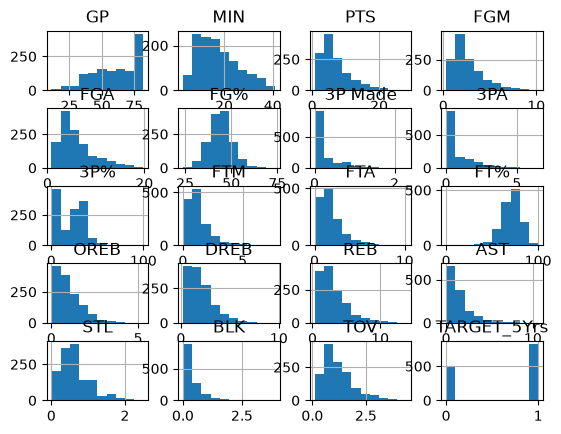

In [9]:
nbaDf.hist()
plt.show()

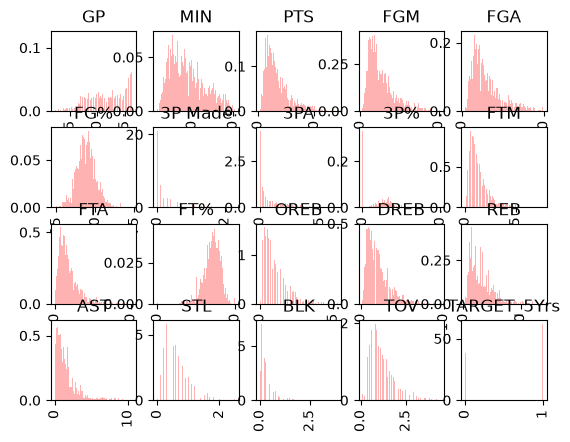

In [12]:
plt.Figure(figsize=(25,25))
for i, col in enumerate(nbaDf.columns[1:]):
    plt.subplot(4,5,i+1)
    plt.hist(nbaDf[col],bins = 100, alpha = 0.3, color= 'r', density= True)
    plt.title(col)
    plt.xticks(rotation = "vertical")

how to choose the number of bins?
bins default = 10 in sciki.

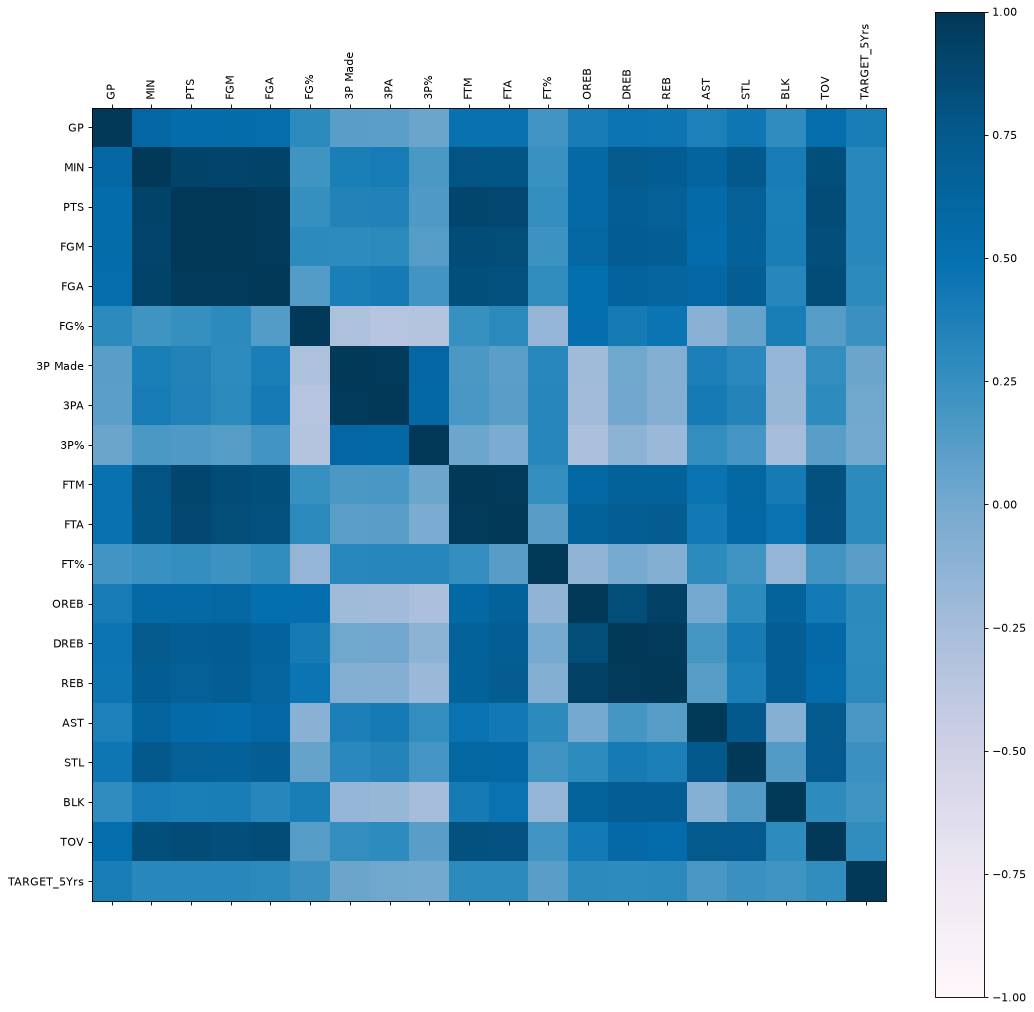

In [17]:
correlation = nbaDf.select_dtypes(include=['number']).corr()

# Correct way: use plt.figure, not plt.Figure
fig = plt.figure(figsize=(16,16), dpi=80)
ax = fig.add_subplot(111)

cax = ax.matshow(correlation, vmin=-1, vmax=1, cmap=plt.cm.PuBu)
fig.colorbar(cax)

ticks = np.arange(0, len(correlation.columns), 1)
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(correlation.columns, rotation=90)
ax.set_yticklabels(correlation.columns)

plt.show()

In [18]:
nbaDf.loc[pd.isna(nbaDf['3P%']), '3P%'] = nbaDf.loc[pd.isna(nbaDf['3P%']), 'FTM']

In [20]:
nba_X = nbaDf.drop(['Name', 'TARGET_5Yrs'], axis=1)
nba_Y = nbaDf['TARGET_5Yrs']

In [21]:
print(nba_X.shape)
print(nba_Y.shape)

(1340, 19)
(1340,)


In [22]:
from sklearn.model_selection import train_test_split

train_X, test_X, train_Y, test_Y = train_test_split(nba_X, nba_Y, test_size= 0.2)
print(train_X.shape)
print(test_X.shape)
print(train_Y.shape)
print(test_Y.shape)

(1072, 19)
(268, 19)
(1072,)
(268,)


In [23]:
train_X, val_X, train_X, val_Y = train_test_split(train_X, train_Y, test_size= 0.25, shuffle=True)
print(train_X.shape)
print(val_X.shape)
print(train_Y.shape)
print(val_Y.shape)
print(val_Y)

(804,)
(268, 19)
(1072,)
(268,)
368     0
405     1
1199    1
1169    1
188     1
       ..
963     0
659     1
609     0
369     0
328     1
Name: TARGET_5Yrs, Length: 268, dtype: int64


In [ ]:
MinMaxScaler